# PLM-only S2F versus original S2F

This notebook loads raw prediction artifacts for every model, calculates model-performance metrics on the shared GOA-derived evaluation proteins, and compares original S2F with PLM-only KNN and KDE S2F. It does not read precomputed metric results.

`prediction.df` and sparse `prediction.npz` are both supported. For NPZ, `proteins.df` and `terms.df` provide the row and column indexes. Scope is `83333` and `1111708`; `223283` and every `cafa_*` artifact are excluded.

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import sparse

plt.rcParams['figure.dpi'] = 120

def find_s2f_root() -> Path:
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / 'S2F.py').is_file() and (candidate / 'scripts').is_dir():
            return candidate
    raise RuntimeError('Run this notebook from S2F or a subdirectory.')

S2F_ROOT = find_s2f_root()
sys.path.insert(0, str(S2F_ROOT / 'scripts'))
import clean_plm_benchmark as benchmark

INSTALLATION_DIR = Path('/run/media/marcelo_baez/HD_Disc1/.S2F')
GOA_PATH = INSTALLATION_DIR / 'data' / 'UniprotKB' / 'filtered_goa'
GO_OBO_PATH = S2F_ROOT / 'go.obo'
RESULT_DIR = S2F_ROOT / 'notebooks' / 'exports' / 'plm_only_s2f_from_predictions'
SAVE_CALCULATED_METRICS = True

ORGANISMS = ('83333', '1111708')
ALL_METRICS = (
    'overall::AUC', 'overall::AUPR',
    'overall::F_max', 'overall::smin',
    'AUC per-gene', 'AUPR per-gene',
    'F_max per-gene','smin per-gene',
    'AUC per-term', 'AUPR per-term',
    'F_max per-term','smin per-term',
)

# Set a path only if an exact original S2F raw run is archived outside INSTALLATION_DIR/output.
ORIGINAL_RUN_OVERRIDES = {'83333': None, '1111708': None}
RUNS = (
    {'organism': '83333', 'model': 'Original S2F', 'alias': '83333', 'original': True},
    {'organism': '83333', 'model': 'PLM S2F (KNN)', 'alias': '83333_plm_knn_k160', 'original': False},
    {'organism': '83333', 'model': 'PLM S2F (KDE)', 'alias': '83333_plm_kde', 'original': False},
    {'organism': '83333', 'model': 'PLM HMMER S2F (KNN)', 'alias': '83333_plm_hmmer_knn_k160', 'original': False},
    {'organism': '83333', 'model': 'PLM HMMER S2F (KDE)', 'alias': '83333_plm_hmmer_kde', 'original': False},
    {'organism': '1111708', 'model': 'Original S2F', 'alias': '1111708', 'original': True},
    {'organism': '1111708', 'model': 'PLM S2F (KNN)', 'alias': '1111708_plm_knn_k80', 'original': False},
    {'organism': '1111708', 'model': 'PLM S2F (KDE)', 'alias': '1111708_plm_kde', 'original': False},
    # {'organism': '1111708', 'model': 'PLM HMMER S2F (KNN)', 'alias': '1111708_plm_hmmer_knn_k80', 'original': False},
    # {'organism': '1111708', 'model': 'PLM HMMER S2F (KDE)', 'alias': '1111708_plm_hmmer_kde', 'original': False},
)
print(f'S2F root: {S2F_ROOT}')

S2F root: /home/marcelo_baez/paccanaro-lab/PFP-Research/S2F


## Raw prediction loader

Large `prediction.df` files are streamed in chunks. NPZ predictions are sliced to evaluation proteins while still sparse; neither loader materializes full non-evaluation matrices.

In [3]:
PREDICTION_COLUMNS = ['protein_id', 'term_id', 'score']

def run_directory(run: dict) -> Path:
    override = ORIGINAL_RUN_OVERRIDES[run['organism']] if run['original'] else None
    return Path(override).expanduser().resolve() if override else INSTALLATION_DIR / 'output' / run['alias']

def prediction_artifact(directory: Path) -> str:
    if (directory / 'prediction.npz').is_file():
        return 'prediction.npz'
    if (directory / 'prediction.df').is_file():
        return 'prediction.df'
    raise FileNotFoundError(f'Missing prediction.df or prediction.npz in {directory}')

def read_prediction_df(path: Path, proteins: set[str], terms: set[str]) -> pd.DataFrame:
    chunks = []
    for chunk in pd.read_csv(
        path, sep='\t', header=None, names=PREDICTION_COLUMNS, usecols=[0, 1, 2],
        dtype={'protein_id': str, 'term_id': str, 'score': np.float32}, chunksize=1_000_000,
    ):
        chunk = chunk[chunk['protein_id'].isin(proteins) & chunk['term_id'].isin(terms)]
        if not chunk.empty:
            chunks.append(chunk)
    if not chunks:
        return pd.DataFrame(columns=PREDICTION_COLUMNS)
    return pd.concat(chunks, ignore_index=True).groupby(['protein_id', 'term_id'], as_index=False)['score'].max()

def read_prediction_npz(directory: Path, proteins: set[str], terms: set[str]) -> pd.DataFrame:
    protein_index = pd.read_pickle(directory / 'proteins.df')
    term_index = pd.read_pickle(directory / 'terms.df')
    matrix = sparse.load_npz(directory / 'prediction.npz').tocsr()
    if matrix.shape != (len(protein_index), len(term_index)):
        raise RuntimeError(f'NPZ/index shape mismatch in {directory}: {matrix.shape}')
    selected = protein_index[protein_index.index.astype(str).isin(proteins)]
    values = matrix[selected['protein idx'].to_numpy(dtype=int)].tocoo()
    protein_ids = selected.index.astype(str).to_numpy()
    term_ids = np.empty(len(term_index), dtype=object)
    term_ids[term_index['term idx'].to_numpy(dtype=int)] = term_index.index.astype(str)
    table = pd.DataFrame({
        'protein_id': protein_ids[values.row], 'term_id': term_ids[values.col],
        'score': values.data.astype(float),
    })
    table = table[table['score'].gt(0) & table['term_id'].isin(terms)]
    return table.groupby(['protein_id', 'term_id'], as_index=False)['score'].max()

def load_predictions(run: dict, proteins: set[str], terms: set[str]):
    directory = run_directory(run)
    artifact = prediction_artifact(directory)
    if artifact == 'prediction.df':
        return read_prediction_df(directory / artifact, proteins, terms), directory, artifact
    return read_prediction_npz(directory, proteins, terms), directory, artifact

## Artifact preflight

Metrics are calculated only if every original and PLM-only run is complete. This prevents an unavailable `prediction.df` or NPZ run from being silently replaced by an old metric table.

In [4]:
availability_rows = []
for run in RUNS:
    directory = run_directory(run)
    try:
        artifact, status = prediction_artifact(directory), 'ready'
    except FileNotFoundError as error:
        artifact, status = '', str(error)
    availability_rows.append({**run, 'directory': str(directory), 'artifact': artifact, 'status': status})
availability = pd.DataFrame(availability_rows)
display(availability[['organism', 'model', 'alias', 'artifact', 'directory', 'status']])
if availability['artifact'].eq('').any():
    raise FileNotFoundError(
        'Raw prediction artifacts are missing. Complete or locate every listed run; the notebook will not use saved metrics instead.'
    )

,organism,model,alias,artifact,directory,status
0,83333,Original S2F,83333,prediction.df,/run/media/marcelo_baez/HD_Disc1/.S2F/output/8...,ready
1,83333,PLM S2F (KNN),83333_plm_knn_k160,prediction.npz,/run/media/marcelo_baez/HD_Disc1/.S2F/output/8...,ready
2,83333,PLM S2F (KDE),83333_plm_kde,prediction.npz,/run/media/marcelo_baez/HD_Disc1/.S2F/output/8...,ready
3,83333,PLM HMMER S2F (KNN),83333_plm_hmmer_knn_k160,prediction.npz,/run/media/marcelo_baez/HD_Disc1/.S2F/output/8...,ready
4,83333,PLM HMMER S2F (KDE),83333_plm_hmmer_kde,prediction.npz,/run/media/marcelo_baez/HD_Disc1/.S2F/output/8...,ready
5,1111708,Original S2F,1111708,prediction.df,/run/media/marcelo_baez/HD_Disc1/.S2F/output/1...,ready
6,1111708,PLM S2F (KNN),1111708_plm_knn_k80,prediction.npz,/run/media/marcelo_baez/HD_Disc1/.S2F/output/1...,ready
7,1111708,PLM S2F (KDE),1111708_plm_kde,prediction.npz,/run/media/marcelo_baez/HD_Disc1/.S2F/output/1...,ready


## Calculate all performance metrics from predictions

Each prediction table is evaluated against the same organism-specific, shared protein set and the same propagated GO ground truth. The calculation includes overall, per-gene, and per-term AUC, AUPR, precision at recall, F-max, NDCG, Jaccard, and Smin.

In [5]:
evaluation_sets, evaluation_summary = benchmark.build_evaluation_sets(GOA_PATH)
metric_rows, provenance_rows = [], []

for organism in ORGANISMS:
    evaluation_proteins = evaluation_sets[organism]
    annotations, ontology, organism_name = benchmark.prepare_ground_truth(
        GOA_PATH, GO_OBO_PATH, organism, evaluation_proteins
    )
    valid_terms = set(annotations['GO ID'].astype(str))
    for run in [item for item in RUNS if item['organism'] == organism]:
        predictions, directory, artifact = load_predictions(run, evaluation_proteins, valid_terms)
        row = benchmark.evaluate_prediction_table(
            run['model'], organism, predictions, annotations, ontology, organism_name,
            len(evaluation_proteins),
            source_note='Calculated from raw prediction artifact by plm_only_s2f_vs_original.ipynb.',
            extra_metadata={'run_alias': run['alias'], 'artifact': artifact, 'artifact_path': str(directory / artifact)},
        )
        missing = [metric for metric in ALL_METRICS if metric not in row]
        if missing:
            raise RuntimeError(f'{run["model"]} {organism} omitted metrics: {missing}')
        metric_rows.append(row)
        provenance_rows.append({**run, 'artifact': artifact, 'artifact_path': str(directory / artifact),
                                'prediction_rows_on_shared_set': len(predictions),
                                'predicted_proteins_on_shared_set': predictions['protein_id'].nunique()})
        print(f'Calculated {run["model"]} for {organism}: {len(predictions):,} prediction rows.')

metrics = pd.DataFrame(metric_rows)
provenance = pd.DataFrame(provenance_rows)
assert len(metrics) == len(RUNS)
display(evaluation_summary[evaluation_summary['organism'].astype(str).isin(ORGANISMS)])
display(provenance)

if SAVE_CALCULATED_METRICS:
    RESULT_DIR.mkdir(parents=True, exist_ok=True)
    metrics.to_csv(RESULT_DIR / 'metrics_from_raw_predictions.csv', index=False)
    provenance.to_csv(RESULT_DIR / 'raw_prediction_provenance.csv', index=False)
    evaluation_summary.to_csv(RESULT_DIR / 'evaluation_protein_sets.csv', index=False)
    print(f'Saved calculated metrics and provenance to {RESULT_DIR}')

Calculated Original S2F for 83333: 90,400 prediction rows.
Calculated PLM S2F (KNN) for 83333: 88,800 prediction rows.
Calculated PLM S2F (KDE) for 83333: 88,960 prediction rows.
Calculated PLM HMMER S2F (KNN) for 83333: 88,800 prediction rows.
Calculated PLM HMMER S2F (KDE) for 83333: 88,960 prediction rows.
Calculated Original S2F for 1111708: 3,069 prediction rows.
Calculated PLM S2F (KNN) for 1111708: 3,069 prediction rows.
Calculated PLM S2F (KDE) for 1111708: 3,069 prediction rows.


,organism,source_model,raw_test_proteins,goa_overlap_proteins,goa_proteins,protein_set_mode
0,83333,ATGO,52910.0,161,3458,intersection
1,83333,PANDA2,12739.0,160,3458,intersection
2,83333,SHARED_EVALUATION_SET,NaN,160,3458,intersection
6,1111708,ATGO,52910.0,33,120,intersection
7,1111708,PANDA2,3392.0,33,120,intersection
8,1111708,SHARED_EVALUATION_SET,NaN,33,120,intersection


,organism,model,alias,original,artifact,artifact_path,prediction_rows_on_shared_set,predicted_proteins_on_shared_set
0,83333,Original S2F,83333,True,prediction.df,/run/media/marcelo_baez/HD_Disc1/.S2F/output/8...,90400,160
1,83333,PLM S2F (KNN),83333_plm_knn_k160,False,prediction.npz,/run/media/marcelo_baez/HD_Disc1/.S2F/output/8...,88800,160
2,83333,PLM S2F (KDE),83333_plm_kde,False,prediction.npz,/run/media/marcelo_baez/HD_Disc1/.S2F/output/8...,88960,160
3,83333,PLM HMMER S2F (KNN),83333_plm_hmmer_knn_k160,False,prediction.npz,/run/media/marcelo_baez/HD_Disc1/.S2F/output/8...,88800,160
4,83333,PLM HMMER S2F (KDE),83333_plm_hmmer_kde,False,prediction.npz,/run/media/marcelo_baez/HD_Disc1/.S2F/output/8...,88960,160
5,1111708,Original S2F,1111708,True,prediction.df,/run/media/marcelo_baez/HD_Disc1/.S2F/output/1...,3069,33
6,1111708,PLM S2F (KNN),1111708_plm_knn_k80,False,prediction.npz,/run/media/marcelo_baez/HD_Disc1/.S2F/output/1...,3069,33
7,1111708,PLM S2F (KDE),1111708_plm_kde,False,prediction.npz,/run/media/marcelo_baez/HD_Disc1/.S2F/output/1...,3069,33


Saved calculated metrics and provenance to /home/marcelo_baez/paccanaro-lab/PFP-Research/S2F/notebooks/exports/plm_only_s2f_from_predictions


In [6]:
metrics

,organism,model,label,plot_label,is_s2f,evaluation_protein_set_size,predicted_proteins_in_evaluation_set,proteins_considered,terms_considered,total_annotations,...,NDCG per-gene,Jaccard per-gene,smin per-gene,AUC per-term,AUPR per-term,Precision at 0.2 Recall per-term,F_max per-term,NDCG per-term,Jaccard per-term,smin per-term
0,83333,Original S2F,Original S2F,Original S2F,False,160,160,160,574,1922,...,0.659815,0.336626,0.117879,0.707290,0.083476,0.275697,0.346394,0.449660,0.282163,0.853519
1,83333,PLM S2F (KNN),PLM S2F (KNN),PLM S2F (KNN),False,160,160,160,574,1922,...,0.764788,0.572567,0.121902,0.713104,0.063230,0.172764,0.265326,0.383440,0.202371,0.635078
2,83333,PLM S2F (KDE),PLM S2F (KDE),PLM S2F (KDE),False,160,160,160,574,1922,...,0.652789,0.389817,0.118825,0.686195,0.065035,0.257840,0.276337,0.394149,0.213113,0.712257
3,83333,PLM HMMER S2F (KNN),PLM HMMER S2F (KNN),PLM HMMER S2F (KNN),False,160,160,160,574,1922,...,0.766295,0.574709,0.116824,0.710185,0.066492,0.239591,0.304544,0.420660,0.244614,0.607780
4,83333,PLM HMMER S2F (KDE),PLM HMMER S2F (KDE),PLM HMMER S2F (KDE),False,160,160,160,574,1922,...,0.651527,0.390060,0.117920,0.697893,0.070938,0.262413,0.295032,0.407221,0.229844,0.769747
5,1111708,Original S2F,Original S2F,Original S2F,False,33,33,33,93,306,...,0.723700,0.453185,0.262880,0.812667,0.239673,0.279570,0.607728,0.649911,0.490034,0.405286
6,1111708,PLM S2F (KNN),PLM S2F (KNN),PLM S2F (KNN),False,33,33,33,93,306,...,0.896060,0.777147,0.215583,0.839019,0.250045,0.505376,0.619888,0.695424,0.514983,0.366490
7,1111708,PLM S2F (KDE),PLM S2F (KDE),PLM S2F (KDE),False,33,33,33,93,306,...,0.824682,0.626670,0.201616,0.878784,0.286362,0.526882,0.695916,0.742208,0.583812,0.349093


In [7]:
metrics_filtered =  metrics.drop(columns=['artifact','run_alias','source_note','overall::Precision at 0.2 Recall', 'Precision at 0.2 Recall per-gene', 'Precision at 0.2 Recall per-term', 'overall::NDCG', 'overall::Jaccard', 'NDCG per-gene', 'Jaccard per-gene', 'NDCG per-term', 'Jaccard per-term', 'artifact_path', 'is_s2f', 'evaluation_protein_set_size', 'predicted_proteins_in_evaluation_set', 'proteins_considered', 'terms_considered', 'total_annotations', 'matrix_shape', 'source_csv'])

In [8]:
metrics_filtered

,organism,model,label,plot_label,overall::AUC,overall::AUPR,overall::F_max,overall::smin,AUC per-gene,AUPR per-gene,F_max per-gene,smin per-gene,AUC per-term,AUPR per-term,F_max per-term,smin per-term
0,83333,Original S2F,Original S2F,Original S2F,0.834233,0.201215,0.315813,83.465409,0.893060,0.258934,0.478701,0.117879,0.707290,0.083476,0.346394,0.853519
1,83333,PLM S2F (KNN),PLM S2F (KNN),PLM S2F (KNN),0.831463,0.239551,0.293277,84.639994,0.889281,0.143262,0.650126,0.121902,0.713104,0.063230,0.265326,0.635078
2,83333,PLM S2F (KDE),PLM S2F (KDE),PLM S2F (KDE),0.817153,0.186094,0.301491,86.017545,0.888898,0.289842,0.508264,0.118825,0.686195,0.065035,0.276337,0.712257
3,83333,PLM HMMER S2F (KNN),PLM HMMER S2F (KNN),PLM HMMER S2F (KNN),0.831975,0.255048,0.313788,82.809372,0.892137,0.203797,0.654545,0.116824,0.710185,0.066492,0.304544,0.607780
4,83333,PLM HMMER S2F (KDE),PLM HMMER S2F (KDE),PLM HMMER S2F (KDE),0.822905,0.190991,0.303275,85.727943,0.890925,0.291876,0.508683,0.117920,0.697893,0.070938,0.295032,0.769747
5,1111708,Original S2F,Original S2F,Original S2F,0.831826,0.301715,0.412478,50.088438,0.899146,0.345787,0.593566,0.262880,0.812667,0.239673,0.607728,0.405286
6,1111708,PLM S2F (KNN),PLM S2F (KNN),PLM S2F (KNN),0.851644,0.446531,0.511078,42.665335,0.938086,0.575574,0.846227,0.215583,0.839019,0.250045,0.619888,0.366490
7,1111708,PLM S2F (KDE),PLM S2F (KDE),PLM S2F (KDE),0.879120,0.416353,0.542373,42.882577,0.926358,0.475482,0.727511,0.201616,0.878784,0.286362,0.695916,0.349093


### Bar Plots

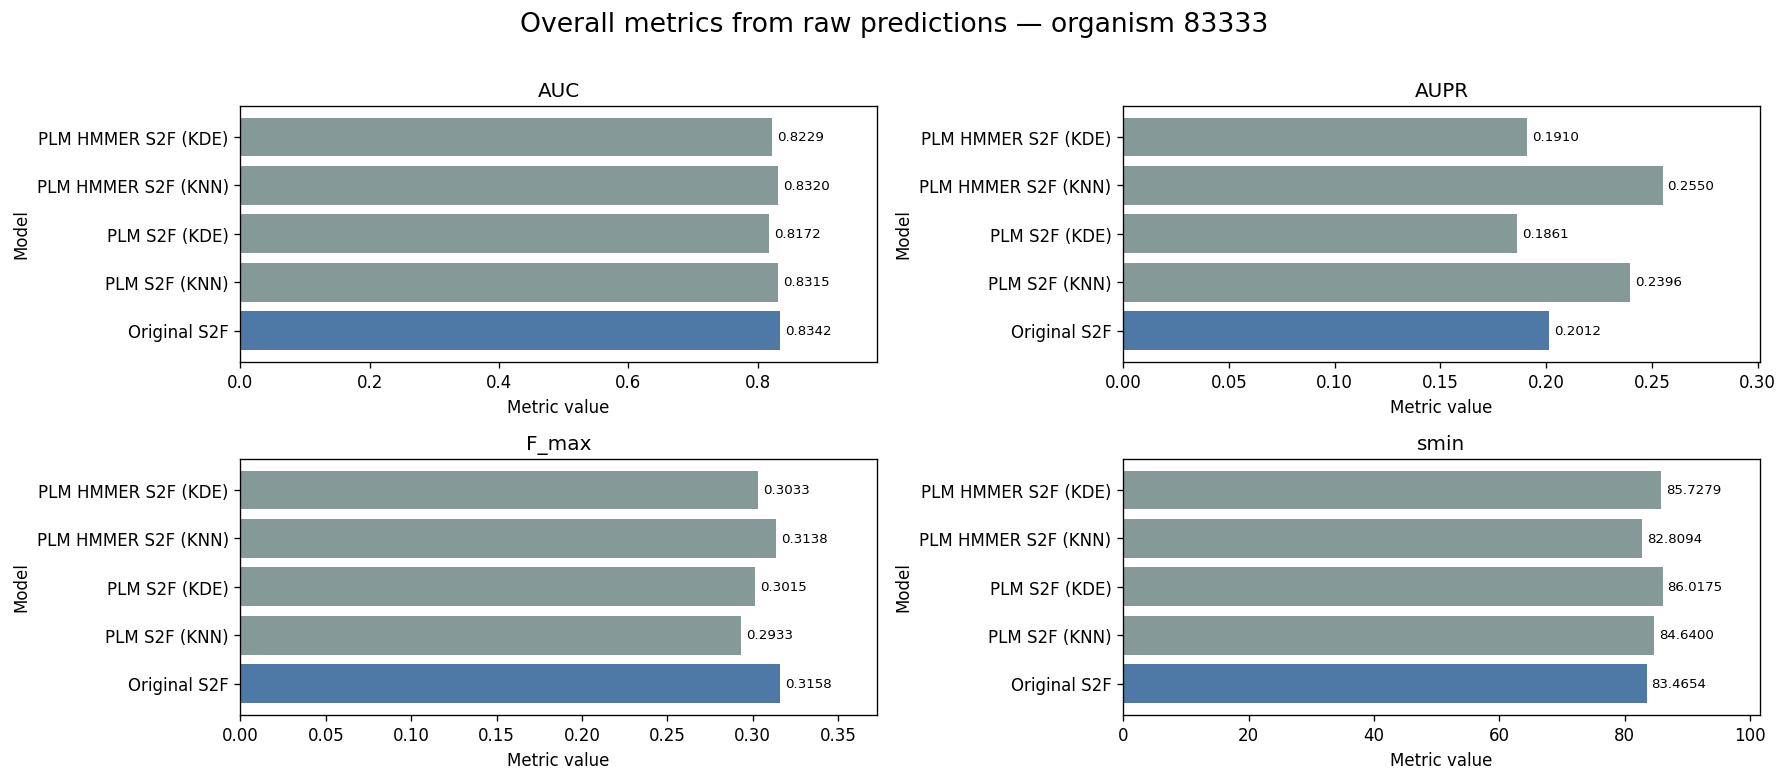

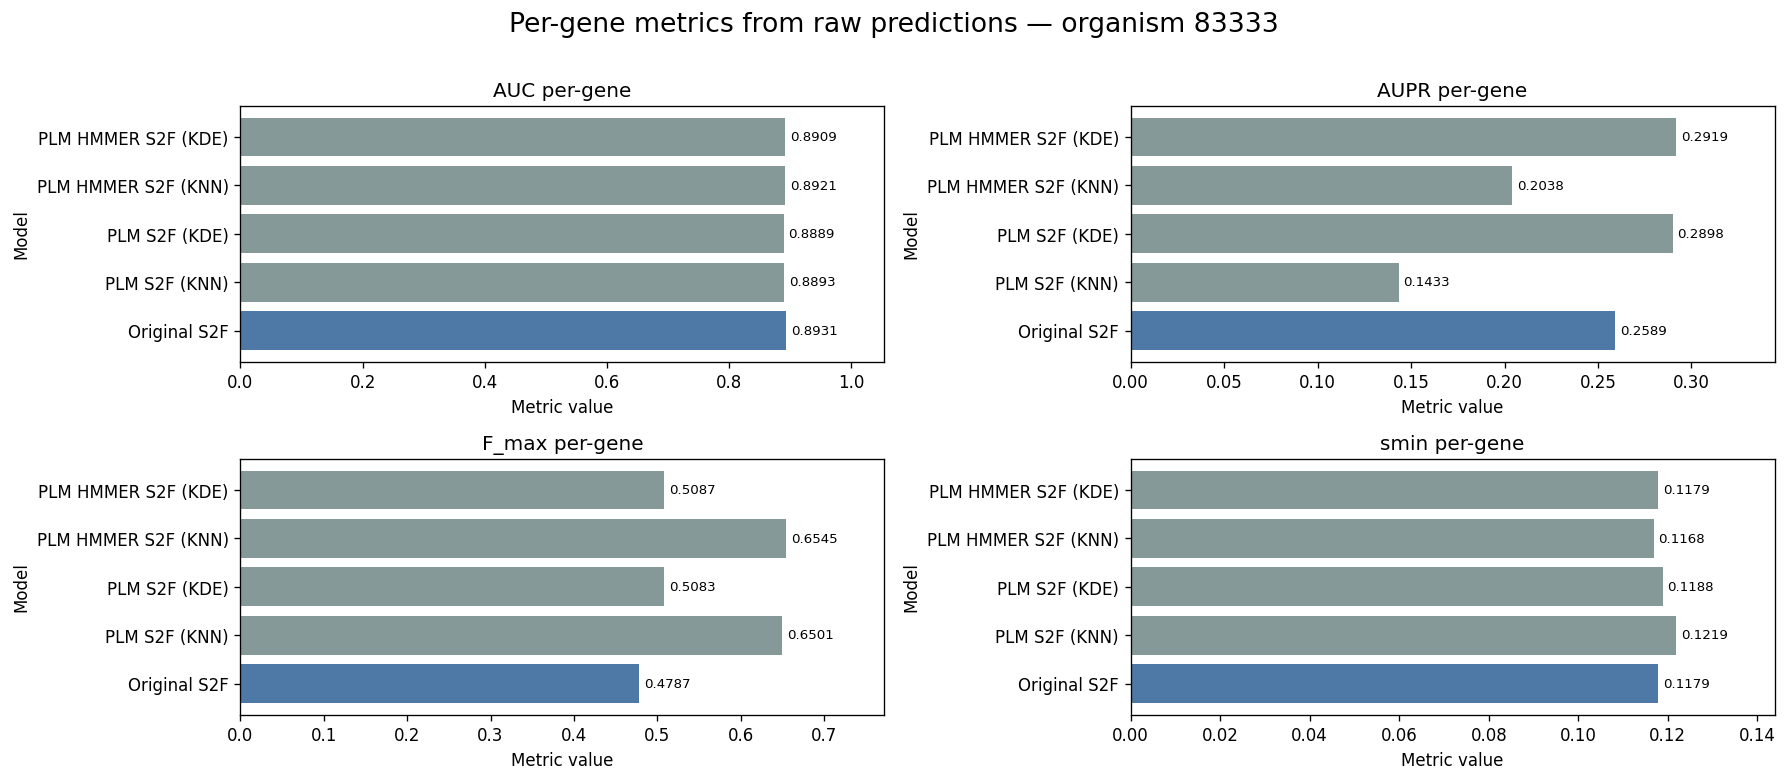

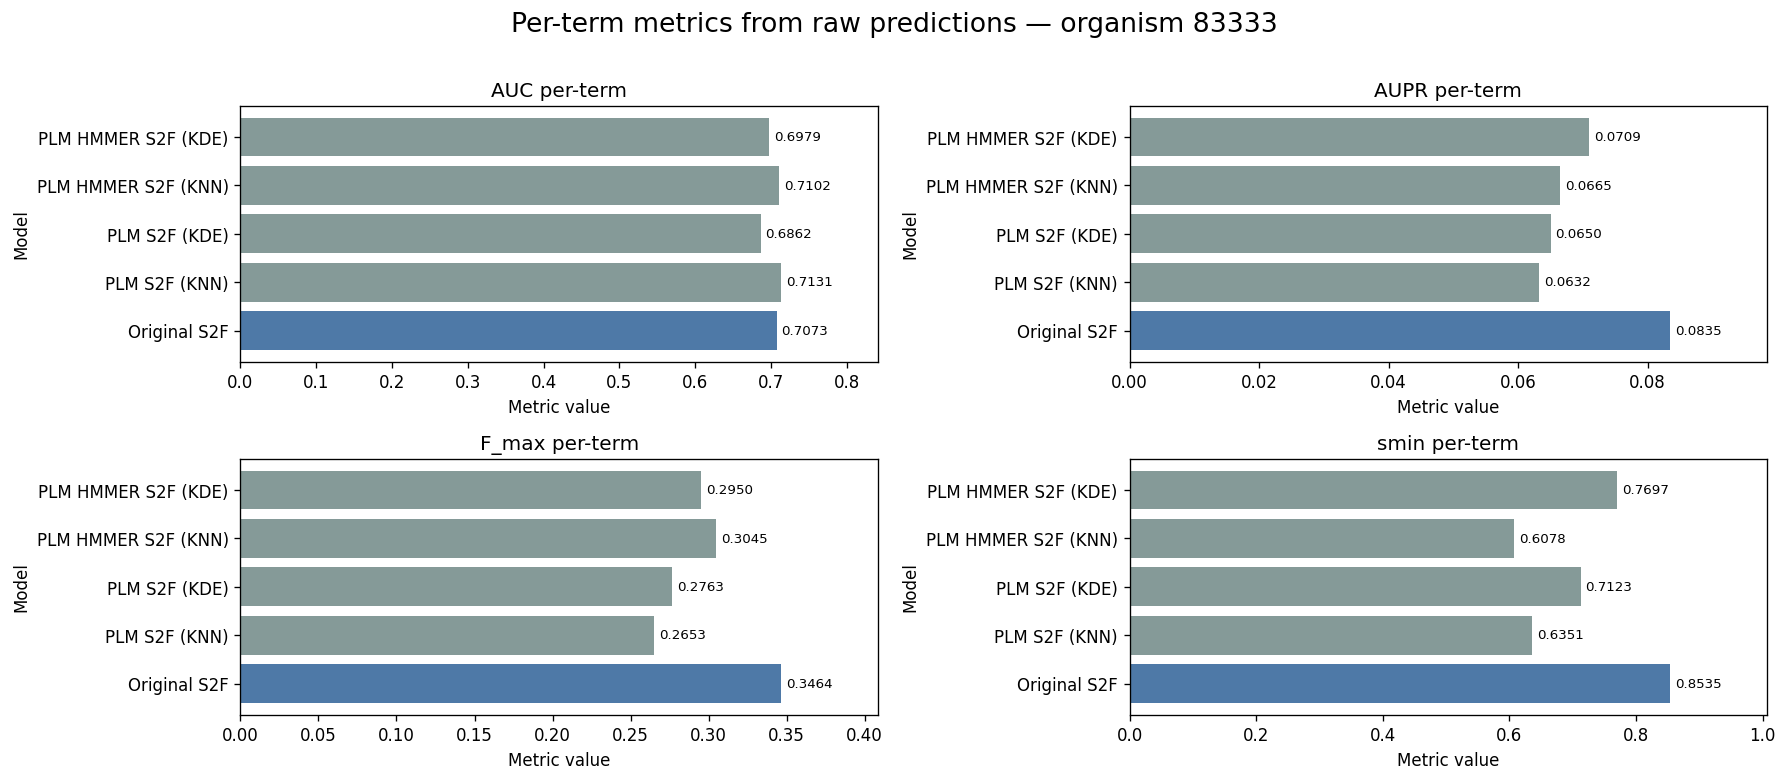

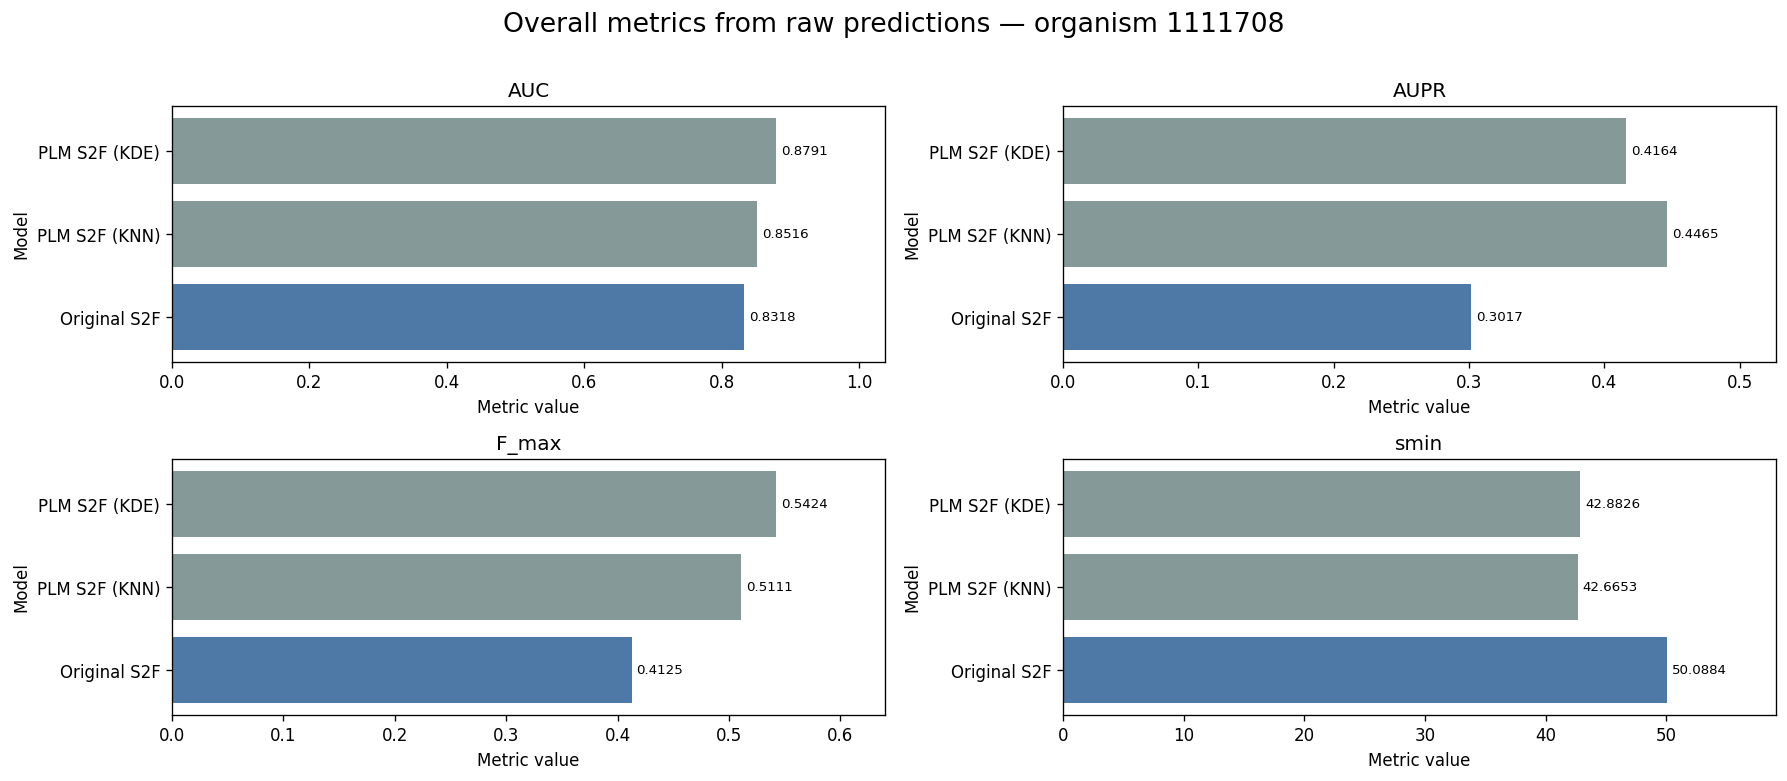

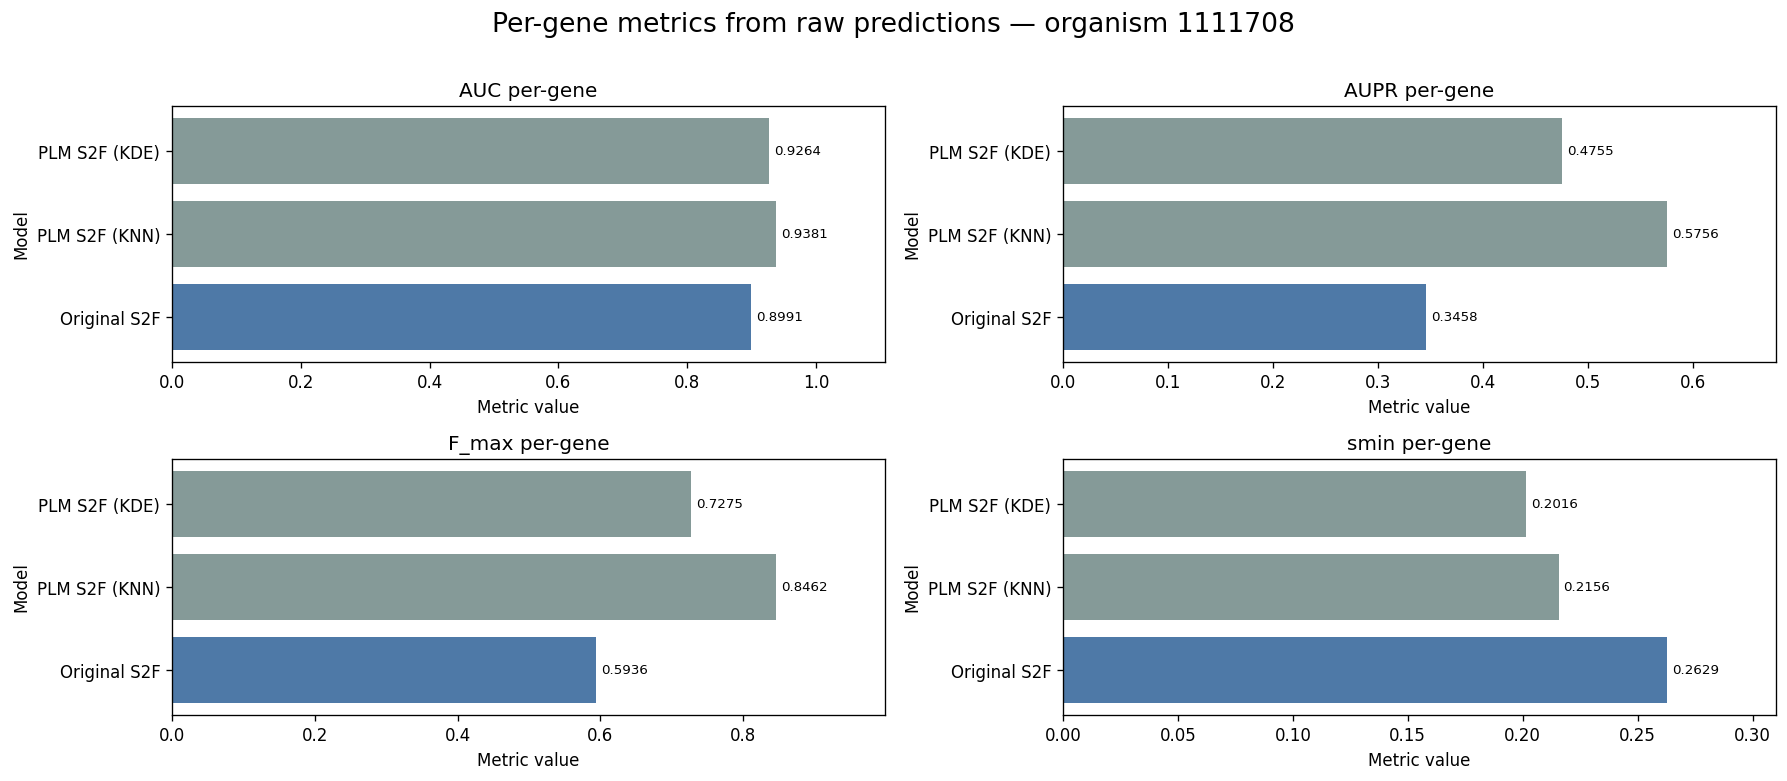

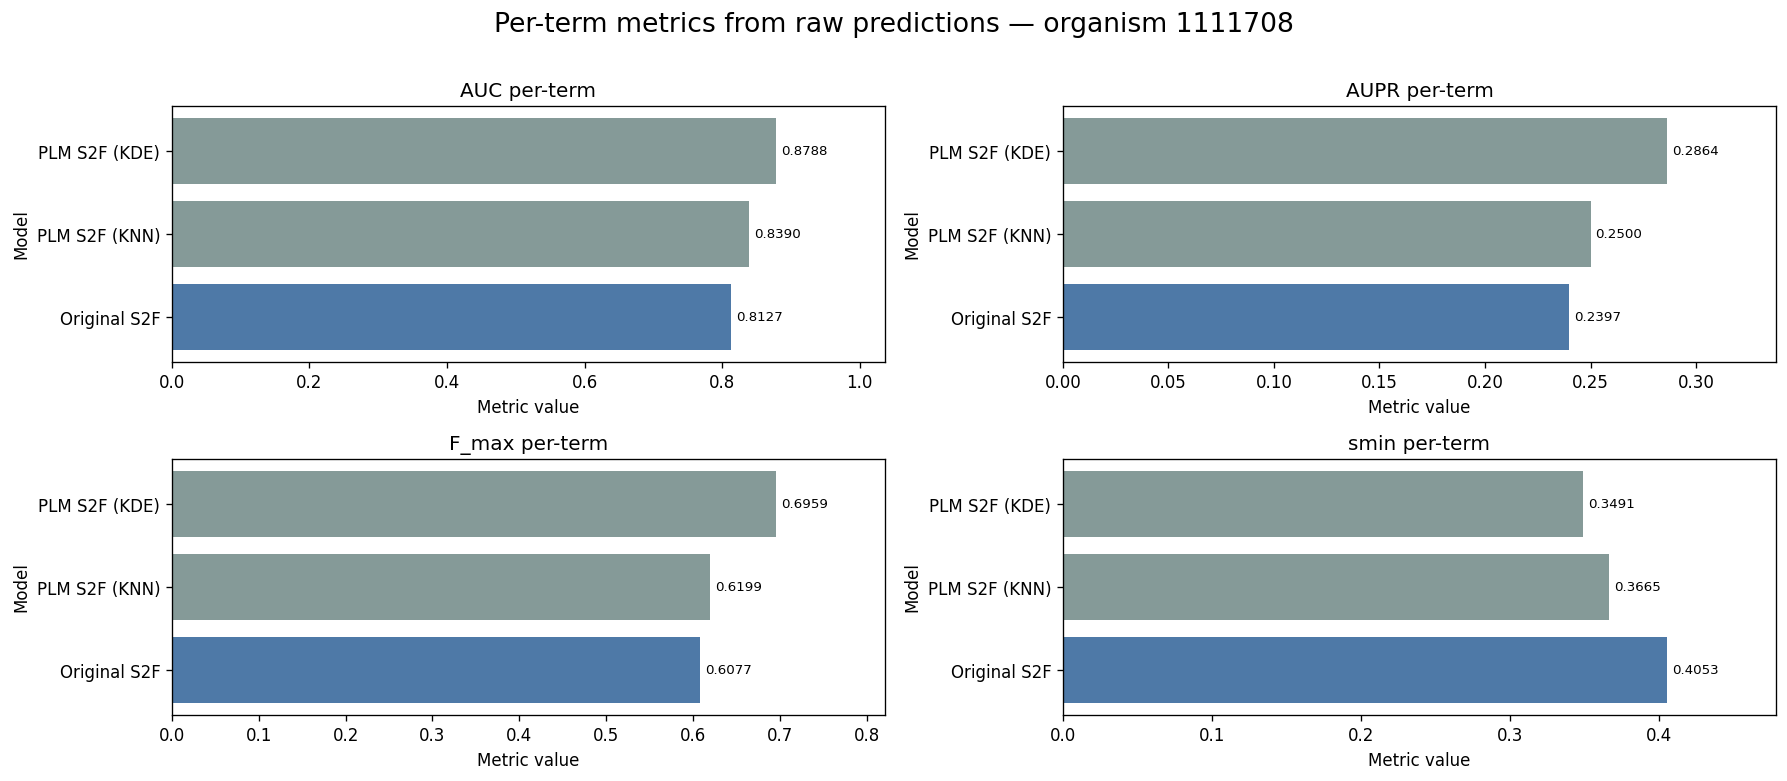

In [9]:
# Three horizontal-bar figure groups per organism: overall, per-gene, and per-term.
METRIC_GROUPS = {
    'Overall': [metric for metric in ALL_METRICS if metric.startswith('overall::')],
    'Per-gene': [metric for metric in ALL_METRICS if metric.endswith(' per-gene')],
    'Per-term': [metric for metric in ALL_METRICS if metric.endswith(' per-term')],
}
# A stable colour per model version makes KNN/KDE and HMMER variants easy to compare.
MODEL_COLORS = {
    'Original S2F': '#4E79A7',
    'PLM S2F (KNN)': '#859A98',
    'PLM S2F (KDE)': '#859A98',
    'PLM HMMER S2F (KNN)': '#859A98',
    'PLM HMMER S2F (KDE)': "#859A98",
}

models = list(metrics_filtered['model'].drop_duplicates())
n_columns = 2

for organism in ORGANISMS:
    organism_metrics = metrics_filtered[metrics_filtered['organism'].astype(str).eq(organism)].copy()
    if organism_metrics.empty:
        raise RuntimeError(f'No calculated metric rows found for organism {organism}.')
    organism_metrics['model'] = pd.Categorical(organism_metrics['model'], categories=models, ordered=True)
    organism_metrics.sort_values('model', inplace=True)

    for group_name, group_metrics in METRIC_GROUPS.items():
        group_metrics = [metric for metric in group_metrics if metric in metrics_filtered.columns]
        if not group_metrics:
            continue
        n_rows = int(np.ceil(len(group_metrics) / n_columns))
        figure, axes = plt.subplots(n_rows, n_columns, figsize=(15, 3.2 * n_rows), squeeze=False)
        for axis, metric in zip(axes.flat, group_metrics):
            values = organism_metrics.set_index('model')[metric].reindex(models)
            bars = axis.barh(models, values, color=[MODEL_COLORS.get(model, '#7F7F7F') for model in models])
            axis.set_title(metric.replace('overall::', ''))
            axis.set_xlabel('Metric value')
            axis.set_ylabel('Model')
            axis.bar_label(bars, labels=[f'{value:.4f}' for value in values], padding=3, fontsize=8)
            axis.margins(x=0.18)
        for axis in axes.flat[len(group_metrics):]:
            axis.set_visible(False)
        figure.suptitle(f'{group_name} metrics from raw predictions — organism {organism}', fontsize=16, y=1.01)
        figure.tight_layout()
        plt.show()
